In [1]:
import os
import pandas as pd
import wave
import numpy as np
from pydub import AudioSegment
from static_ffmpeg import add_paths
import matplotlib.pyplot as plt

C:\Users\jagod\miniconda3\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


<h4>Sprawdzenie ile jest nagrań w każdym z rozważanych gatunków</h4>

In [2]:
all_data = []
path = "./data"

for filename in os.listdir(path):
    f_path = os.path.join(path, filename)
    label = filename.split(' ')[0] # pliki dzwiękowe mają takie nazwy: "0 (1).m4a" gdzie pierwsza cyfra mówi o gatunku a druga w nawiasie o numerze nagrania danego gatunku
    all_data.append({'file_path': f_path,
            'label': label})

df_all = pd.DataFrame(all_data)
df_all['label'] = df_all['label'].astype(int) #zmiana cyfr oznaczających gatunke na int

print(f"Ilość wszystkich plików: {len(df_all)}")
print("Liczba nagrań dla każdego gatunku:")
print(df_all['label'].value_counts().sort_index()) #sortowanie od 0 do 25

Ilość wszystkich plików: 1536
Liczba nagrań dla każdego gatunku:
label
0     70
1     85
2     52
3     50
4     30
5     75
6     53
7     50
8     50
9     50
10    40
11    50
12    42
13    55
14    70
15    66
16    81
17    76
18    50
19    72
20    73
21    70
22    70
23    50
24    51
25    55
Name: count, dtype: int64


<h4> Przekonwertowanie plików z nagraniami z formatu .m4a na .wav za pomocą ffmpeg.</h4>

In [20]:
add_paths()
wav_dir = "./data_wav"
os.makedirs(wav_dir)

wav_files = []

for index, row in df_all.iterrows():
    m4a_path = row['file_path']
    filename = os.path.basename(m4a_path)
    
    wav_filename = filename.replace('.m4a', '.wav')
    new_wav_path = os.path.join(wav_dir, wav_filename)
    
    audio = AudioSegment.from_file(m4a_path, format="m4a")
    audio.export(new_wav_path, format="wav")#eksportowanie pliku na wav
        
    wav_files.append(new_wav_path)

df_all['wav_path'] = wav_files


Download of https://github.com/zackees/ffmpeg_bins/raw/main/v8.0/win32.zip -> C:\Users\jagod\miniconda3\Lib\site-packages\static_ffmpeg\bin\win32.zip completed.
Extracting C:\Users\jagod\miniconda3\Lib\site-packages\static_ffmpeg\bin\win32.zip -> C:\Users\jagod\miniconda3\Lib\site-packages\static_ffmpeg\bin


<h4>Wizualizacja przykładowych sygnałów z pierwszych 5 grup</h4>

In [3]:
def load_sounds(path):
    with wave.open(path, "r") as f:
        frames = f.readframes(f.getnframes())
        data = np.frombuffer(frames, dtype=np.int16).astype(np.float32)
        print(f.getparams())
    return data

s0 = load_sounds("./data_wav/0 (1).wav") 
s1 = load_sounds("./data_wav/1 (1).wav")
s2 = load_sounds("./data_wav/2 (1).wav")
s3 = load_sounds("./data_wav/3 (1).wav")
s4 = load_sounds("./data_wav/4 (1).wav")

_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=92160, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=122880, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=83968, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=130048, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=115712, comptype='NONE', compname='not compressed')


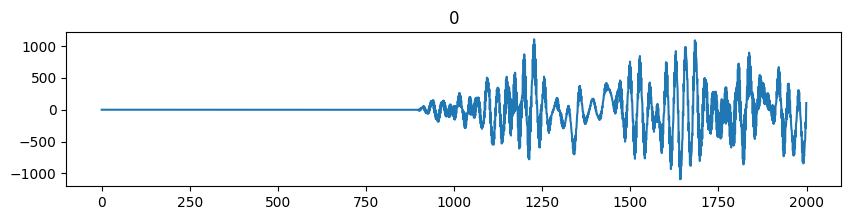

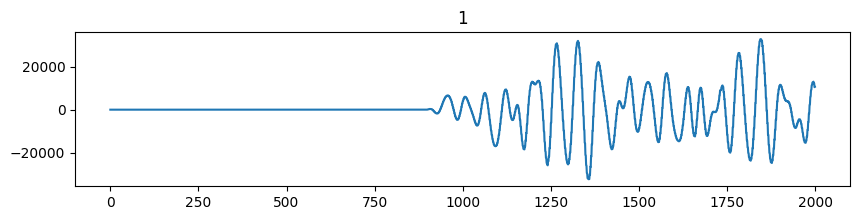

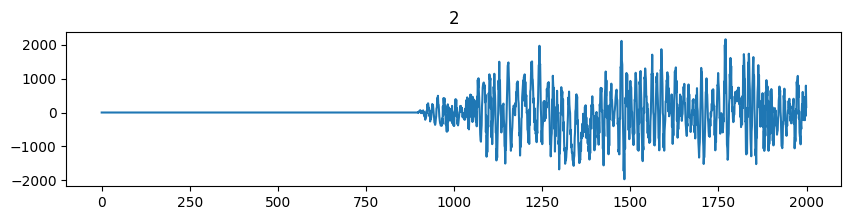

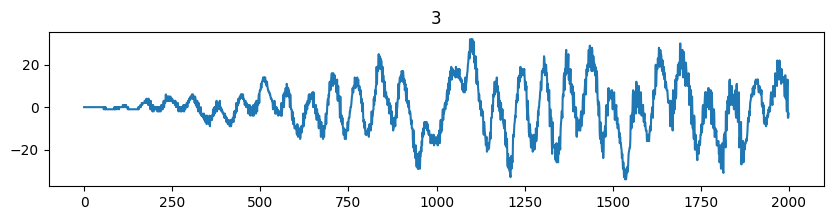

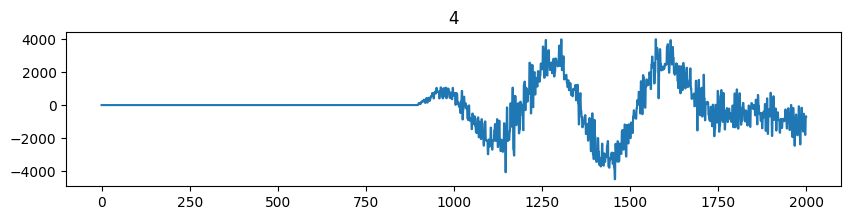

In [4]:
signals = [s0, s1, s2, s3, s4]
names = ["0", "1", "2", "3", "4"]

for sig, name in zip(signals, names):
    plt.figure(figsize=(10, 2)) 
    plt.plot(sig[:2000])
    plt.title(name)
    plt.show()

<h4>Zamiana plików .wav pochodzących od pierwszych 10 klas na reprezentację liczbową ponownie używając funkcji load_sounds</h4>

In [5]:
waves = {}
path_folder = "./data_wav"

all_files = [f for f in os.listdir(path_folder) if f.endswith('.wav')]

unique_classes = set()
for filename in all_files:
    class_part = filename.split(' ')[0]
    unique_classes.add(int(class_part))

target_classes = sorted(list(unique_classes))[:10] #pierwsze 10 klas

#Zamiana plików na reprezentację liczbową
for filename in all_files: 
    class_part = filename.split(' ')[0]
    file_class = int(class_part)

    if file_class in target_classes:
        full_path = os.path.join(path_folder, filename)
        signal = load_sounds(full_path)
        key_name = filename.replace(".wav", "").replace(" ", "") 
        waves[key_name] = signal

_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=92160, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=93184, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=101376, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=113664, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=132096, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=122880, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=126976, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=137216, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=126976, co

<h4>Przykładowy plik dźwiękowy zaprezentowany liczbowo</h4>

[  0.   0.   0. ... -19.  12. -18.]


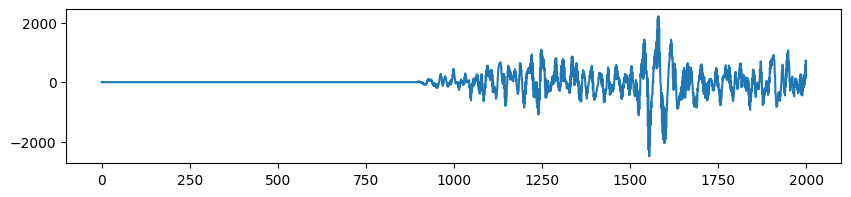

In [6]:
print(waves['8(10)'])

signal = waves['8(10)']
 
plt.figure(figsize=(10, 2)) 
plt.plot(signal[:2000])
plt.show()

<h2>Tworzenie modelu do rozpoznawania odgłosów żab i ropuch</h2>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn as nn
import torch.optim as optim

<h4>Wyrównanie długości nagrań</h4>

In [8]:
max_len = max(len(s) for s in waves.values())#Sprawdzenie długości najdłuższego pliku

In [9]:
sampling_rate = 48000 #częstotliwość próbkowania (z parametrów plików .wav)
n_channels = 2
longest_one = max_len/(sampling_rate*n_channels) #obliczenie czasu trwania nagrania w sekundach
print(f"Długość najdłuższego nagrania w sekundach: {longest_one:.1f}")

Długość najdłuższego nagrania w sekundach: 5.2


In [10]:
min_len = min(len(s) for s in waves.values())#Sprawdzenie długości najkrótszego pliku

In [11]:
sampling_rate = 48000 #częstotliwość próbkowania (z parametrów plików .wav)
n_channels = 2
shortest_one = min_len/(sampling_rate*n_channels) #obliczenie czasu trwania nagrania w sekundach
print(f"Długość najkrótszego nagrania w sekundach: {shortest_one:.1f}")

Długość najkrótszego nagrania w sekundach: 1.3


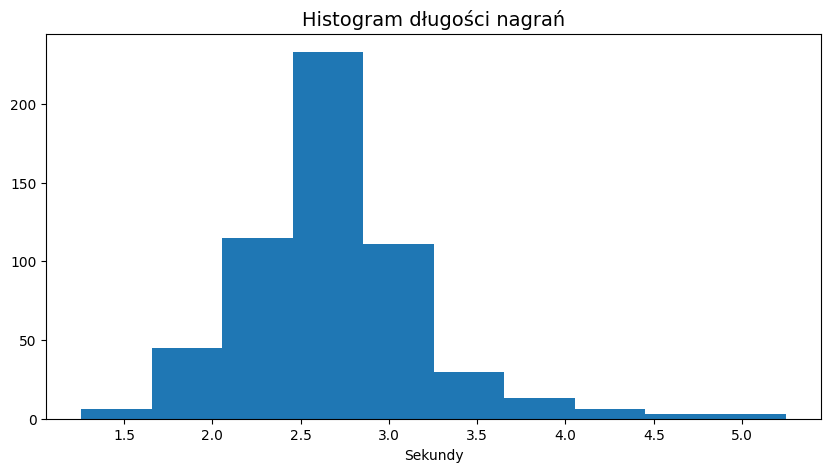

In [12]:
#Histogram rozkładu długości nagrań w sekundach
sampling_rate = 48000
n_channels = 2
durations_sec = [len(s)/(sampling_rate*n_channels) for s in waves.values()]

plt.figure(figsize=(10, 5))
plt.hist(durations_sec)

plt.title('Histogram długości nagrań', fontsize=14)
plt.xlabel('Sekundy')
plt.show()

In [13]:
#Wyrównanie długośc nagrań do 2.5 sekund poprzez obcięcie zbyt długich i zastosowanie paddingu w przypadku za krótkich
sampling_rate = 48000
n_channels = 2
target_len = int(2.5 * n_channels * sampling_rate)  #przeliczenie sekund na próbki

X = []
y = []

for key, signal in waves.items():
    if len(signal) > target_len:
        processed_signal = signal[:target_len]
    else:
        processed_signal = np.pad(signal, (0, target_len - len(signal)), mode='constant') #padding zerami
    X.append(processed_signal)
    label = int(key.split('(')[0]) # ponieważ każda reprezentacja liczbowa jest nazwana w taki sposób np. 7(8) gdzie pierwsza cyfra mówi o gatunku a druga w nawiasie o numerze nagrania danego gatunku
    y.append(label)
    
X = np.array(X)
y = np.array(y)

<h4>Podział danych na zbiór treningowy 70%, testowy 10% i walidacyjny 20%</h4>

In [14]:
# Wydzielenie 10% danych na zbiór testowy
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
 
# WWydzielenie 20% na walidację z pozostałych 90% danych -> 0.20/0.90 = 0.2222
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp)
 
print(f"Trening: {X_train.shape[0]}")
print(f"Walidacja: {X_val.shape[0]}")
print(f"Test: {X_test.shape[0]}")

Trening: 395
Walidacja: 113
Test: 57


<h4>Sprawdzenie liczności każdego gatunku w danym zbiorze (treningowy, testowy i walidacyjny)</h4>

In [15]:
def class_counts(y_label, class_name):
    classes, counts = np.unique(y_label, return_counts=True)
    print("---------------------------------------------")
    print(f'Zbiór {class_name}')
    for cl, co in zip(classes, counts):
        print(f"Klasa {cl} - ilość przykładów:{co}")
 
class_counts(y_train, "Zbiór treningowy")
class_counts(y_val, "Zbiór walidacyjny")
class_counts(y_test, "Zbiór testowy")

---------------------------------------------
Zbiór Zbiór treningowy
Klasa 0 - ilość przykładów:49
Klasa 1 - ilość przykładów:59
Klasa 2 - ilość przykładów:37
Klasa 3 - ilość przykładów:35
Klasa 4 - ilość przykładów:21
Klasa 5 - ilość przykładów:52
Klasa 6 - ilość przykładów:37
Klasa 7 - ilość przykładów:35
Klasa 8 - ilość przykładów:35
Klasa 9 - ilość przykładów:35
---------------------------------------------
Zbiór Zbiór walidacyjny
Klasa 0 - ilość przykładów:14
Klasa 1 - ilość przykładów:17
Klasa 2 - ilość przykładów:10
Klasa 3 - ilość przykładów:10
Klasa 4 - ilość przykładów:6
Klasa 5 - ilość przykładów:15
Klasa 6 - ilość przykładów:11
Klasa 7 - ilość przykładów:10
Klasa 8 - ilość przykładów:10
Klasa 9 - ilość przykładów:10
---------------------------------------------
Zbiór Zbiór testowy
Klasa 0 - ilość przykładów:7
Klasa 1 - ilość przykładów:9
Klasa 2 - ilość przykładów:5
Klasa 3 - ilość przykładów:5
Klasa 4 - ilość przykładów:3
Klasa 5 - ilość przykładów:8
Klasa 6 - ilość przykł

<h4>Standaryzacja danych</h4>

In [16]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

<h4>Tworzenie tensorów</h4>

In [17]:
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_sc, dtype=torch.float32).unsqueeze(1)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_sc, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.long)

<h4>Tworzenie obiektów Dataset i DataLoader do obsługi batchów</h4>

In [18]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

<h4>Funkcja get_accuracy</h4>

In [19]:
def get_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

<h4>Funkcja training_model</h4>

In [20]:
def training_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    losses = []
    train_acc = []
    val_acc = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
    
        for signals, labels in train_loader:
            signals = signals.to(device)
            labels = labels.to(device)
    
            # Forward
            outputs = model(signals)
            loss = criterion(outputs, labels)
    
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
    
        # Średnia strata z epoki
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        train_accuracy = correct_train / total_train

        val_accuracy = get_accuracy(model, val_loader, device) 
    
        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)
    
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, "
              f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")
    
    # Wykres funkcji kosztu
    plt.plot(losses)
    plt.title("Loss per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    
    # Wykres dokładności
    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.title("Accuracy per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return losses, train_acc, val_acc

In [21]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

<h4>Model 1</h4>

In [22]:
class FrogNet_1(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(5*48000, num_classes)
        )

    def forward(self, x):
        return self.main(x)

Epoch 1/5, Loss: 26.3012, Train Acc: 0.0987, Val Acc: 0.1239
Epoch 2/5, Loss: 1.4965, Train Acc: 0.8810, Val Acc: 0.1858
Epoch 3/5, Loss: 0.0868, Train Acc: 0.9899, Val Acc: 0.1858
Epoch 4/5, Loss: 0.0479, Train Acc: 0.9924, Val Acc: 0.2035
Epoch 5/5, Loss: 0.0191, Train Acc: 0.9975, Val Acc: 0.1947


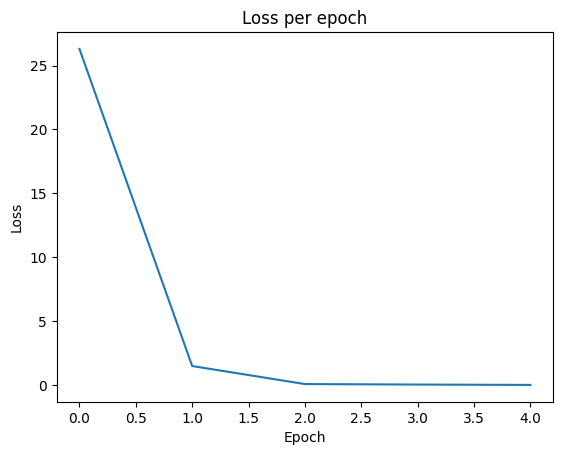

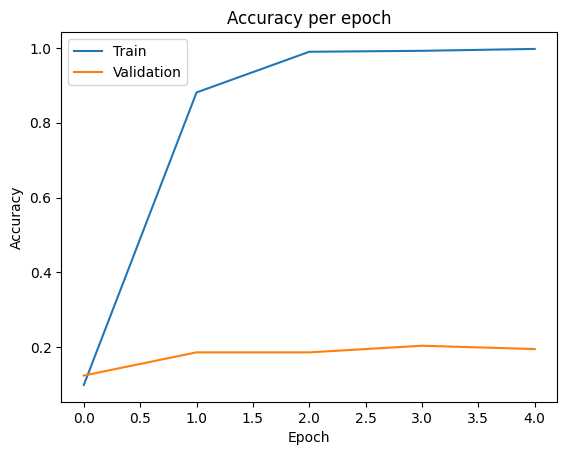

In [23]:
model = FrogNet_1(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

losses, train_acc, val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, 
                                            num_epochs=num_epochs, device=device)

<h4>Funkcja show_classification_report</h4>

In [24]:
def show_classification_report(model, loader, device, class_names=None):
    model.to(device)
    model.eval() 
    
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)

            outputs = model(signals)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_trues.extend(labels.cpu().numpy())
            
    print(classification_report(all_trues, all_preds, zero_division=0))

In [67]:
show_classification_report(model, test_loader, device)

              precision    recall  f1-score   support

           0       0.25      0.14      0.18         7
           1       0.25      0.11      0.15         9
           2       0.50      0.20      0.29         5
           3       0.20      1.00      0.33         5
           4       0.20      0.33      0.25         3
           5       1.00      0.12      0.22         8
           6       0.50      0.20      0.29         5
           7       0.50      0.20      0.29         5
           8       0.14      0.20      0.17         5
           9       0.20      0.20      0.20         5

    accuracy                           0.25        57
   macro avg       0.37      0.27      0.24        57
weighted avg       0.40      0.25      0.23        57



<h4>Model 2</h4>

In [25]:
class FrogNet_2(nn.Module):
    def __init__(self, num_classes=10):
        super(FrogNet_2, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=16, stride=4, padding=32),
            nn.BatchNorm1d(16), 
            nn.ReLU(),
            nn.MaxPool1d(8)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7501, 128),
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
 
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

Epoch 1/5, Loss: 34.9792, Train Acc: 0.1468, Val Acc: 0.1770
Epoch 2/5, Loss: 2.5868, Train Acc: 0.1418, Val Acc: 0.0796
Epoch 3/5, Loss: 2.2327, Train Acc: 0.1367, Val Acc: 0.0885
Epoch 4/5, Loss: 2.2748, Train Acc: 0.1392, Val Acc: 0.0885
Epoch 5/5, Loss: 2.2187, Train Acc: 0.1570, Val Acc: 0.2212


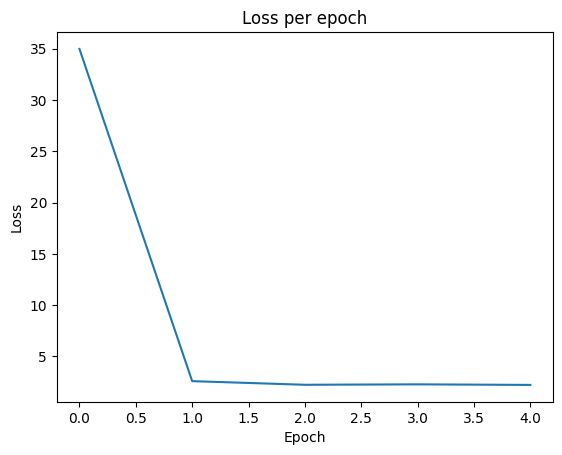

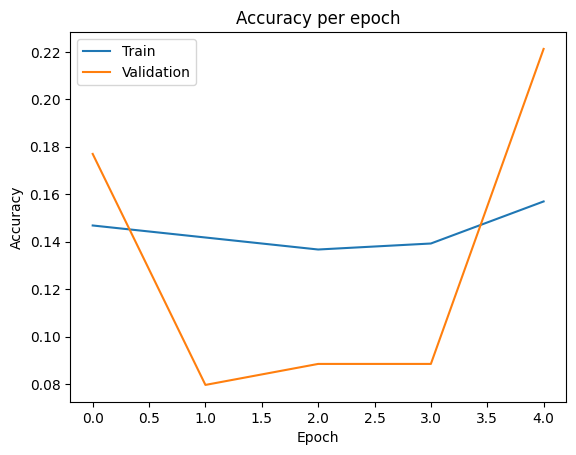

In [26]:
model_2 = FrogNet_2(num_classes=10).to(device)
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001)
num_epochs = 5

losses, train_acc, val_acc = training_model(model=model_2, train_loader=train_loader, val_loader=val_loader, criterion=criterion, 
                                            optimizer=optimizer_2, num_epochs=num_epochs, device=device)

In [27]:
show_classification_report(model_2, test_loader, device)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.64      0.78      0.70         9
           2       0.50      0.20      0.29         5
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         8
           6       1.00      0.40      0.57         5
           7       1.00      0.40      0.57         5
           8       0.13      1.00      0.23         5
           9       0.00      0.00      0.00         5

    accuracy                           0.30        57
   macro avg       0.33      0.28      0.24        57
weighted avg       0.33      0.30      0.26        57



<h4>Model 3</h4>

In [28]:
class FrogNet_3(nn.Module):
    def __init__(self, num_classes=10):
        super(FrogNet_3, self).__init__()
        
        self.features = nn.Sequential(
            # Blok 1
            nn.Conv1d(1, 16, kernel_size=16, stride=4, padding=32),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(8),
            
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4) 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(32 * 1875, 128), 
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

Epoch 1/5, Loss: 8.4478, Train Acc: 0.2810, Val Acc: 0.3186
Epoch 2/5, Loss: 2.1535, Train Acc: 0.3620, Val Acc: 0.3805
Epoch 3/5, Loss: 1.7843, Train Acc: 0.3468, Val Acc: 0.4159
Epoch 4/5, Loss: 1.6972, Train Acc: 0.3949, Val Acc: 0.3982
Epoch 5/5, Loss: 1.5993, Train Acc: 0.3975, Val Acc: 0.3717


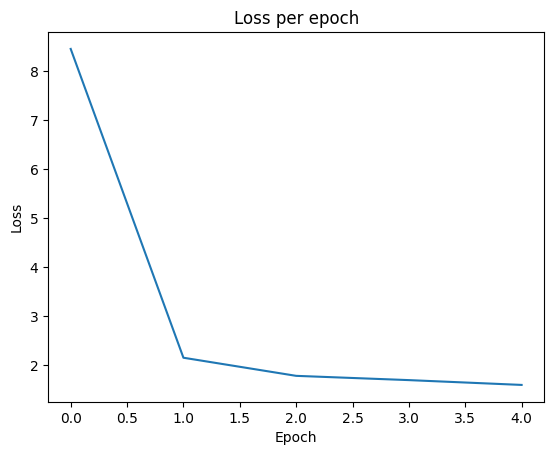

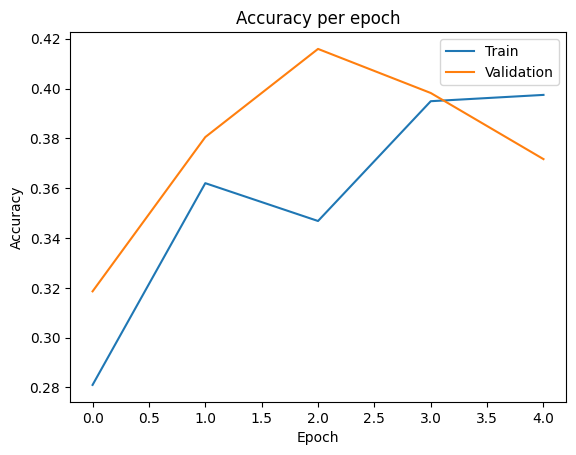

In [29]:
model_3 = FrogNet_3(num_classes=10).to(device)
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.001)
num_epochs = 5

losses, train_acc, val_acc = training_model(model=model_3, train_loader=train_loader, val_loader=val_loader, criterion=criterion, 
                                            optimizer=optimizer_3, num_epochs=num_epochs, device=device)

In [30]:
show_classification_report(model_3, test_loader, device)

              precision    recall  f1-score   support

           0       0.67      0.29      0.40         7
           1       0.75      1.00      0.86         9
           2       0.67      0.40      0.50         5
           3       0.00      0.00      0.00         5
           4       0.33      0.33      0.33         3
           5       0.46      0.75      0.57         8
           6       0.38      0.60      0.46         5
           7       1.00      0.20      0.33         5
           8       0.36      1.00      0.53         5
           9       0.00      0.00      0.00         5

    accuracy                           0.51        57
   macro avg       0.46      0.46      0.40        57
weighted avg       0.49      0.51      0.44        57



<h4>Model 4</h4>

In [31]:
class FrogNet_4(nn.Module):
    def __init__(self, num_classes=10):
        super(FrogNet_4, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=4, padding=32), 
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(8),
 
            nn.Conv1d(16, 32, kernel_size=16, stride=1, padding=8),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.AdaptiveAvgPool1d(16) 
        )
 
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(128, num_classes)
        )
 
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) 
        return self.classifier(x)

Epoch 1/5, Loss: 2.0779, Train Acc: 0.2633, Val Acc: 0.3805
Epoch 2/5, Loss: 1.6167, Train Acc: 0.4456, Val Acc: 0.4779
Epoch 3/5, Loss: 1.3518, Train Acc: 0.5215, Val Acc: 0.6106
Epoch 4/5, Loss: 1.1903, Train Acc: 0.5848, Val Acc: 0.5752
Epoch 5/5, Loss: 1.0647, Train Acc: 0.5975, Val Acc: 0.6549


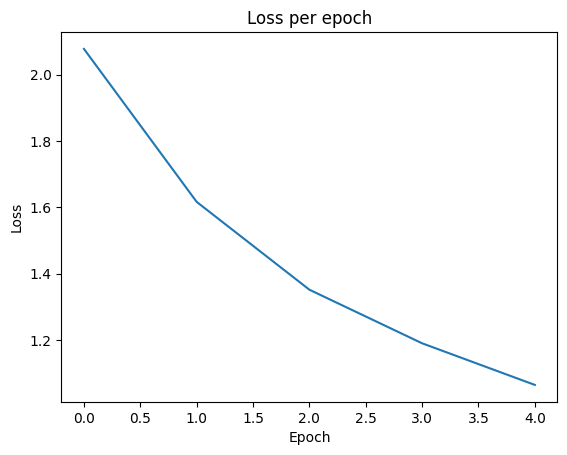

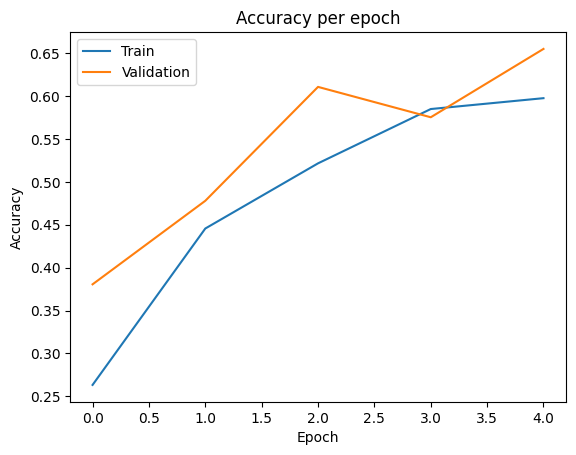

In [32]:
model_4 = FrogNet_4(num_classes=10).to(device)
optimizer_4 = optim.Adam(model_4.parameters(), lr=0.001)
num_epochs = 5

losses, train_acc, val_acc = training_model(model=model_4, train_loader=train_loader, val_loader=val_loader, criterion=criterion, 
                                            optimizer=optimizer_4, num_epochs=num_epochs, device=device)

In [33]:
show_classification_report(model_4, test_loader, device)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.82      1.00      0.90         9
           2       0.80      0.80      0.80         5
           3       0.36      1.00      0.53         5
           4       1.00      0.33      0.50         3
           5       0.89      1.00      0.94         8
           6       0.80      0.80      0.80         5
           7       1.00      0.40      0.57         5
           8       0.00      0.00      0.00         5
           9       0.67      0.40      0.50         5

    accuracy                           0.72        57
   macro avg       0.72      0.66      0.64        57
weighted avg       0.73      0.72      0.69        57



<h4>Confusion matrix na najlepszym modelu</h4>

In [34]:
# Confusion Matrix
def plot_confusion_matrix(model_to_test, loader):
    model_to_test.eval()
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            outputs = model_to_test(signals) 
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_trues.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_trues, all_preds)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot(ax=ax, cmap = 'Greens', values_format='d')
    
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

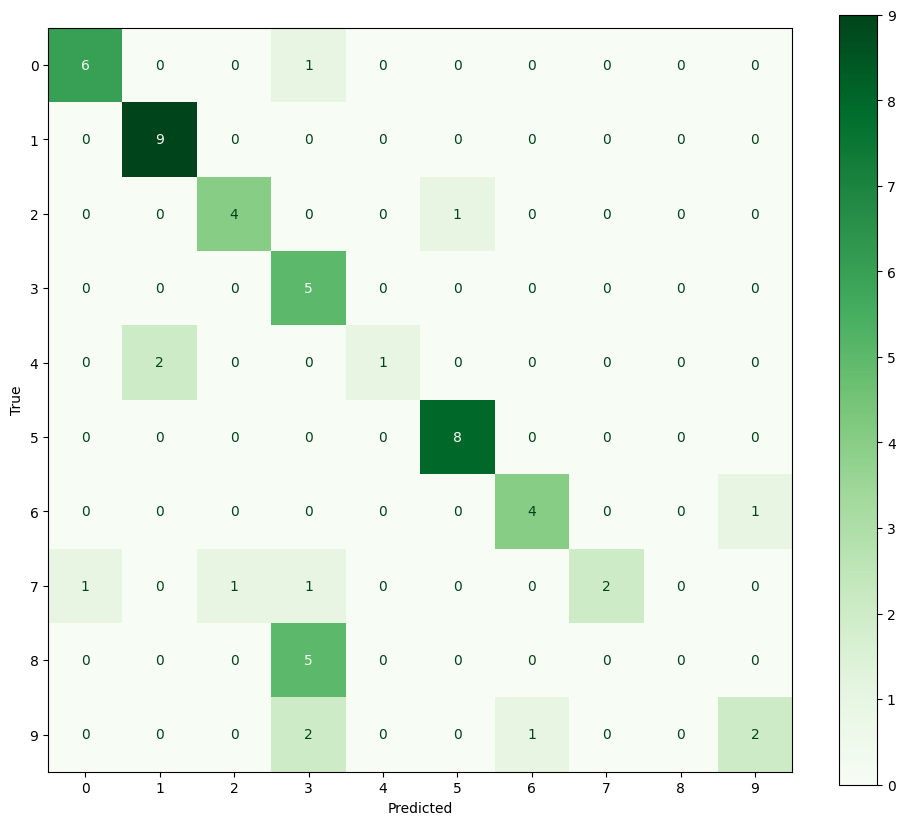

In [35]:
plot_confusion_matrix(model_4, test_loader)

<h4>Dotrenowanie modelu 4 na większej liczbie epok</h4>

Epoch 1/30, Loss: 2.0218, Train Acc: 0.2759, Val Acc: 0.4425
Epoch 2/30, Loss: 1.5012, Train Acc: 0.4810, Val Acc: 0.5398
Epoch 3/30, Loss: 1.2735, Train Acc: 0.5823, Val Acc: 0.6372
Epoch 4/30, Loss: 1.0798, Train Acc: 0.6000, Val Acc: 0.6991
Epoch 5/30, Loss: 0.9629, Train Acc: 0.6759, Val Acc: 0.7522
Epoch 6/30, Loss: 0.8125, Train Acc: 0.7114, Val Acc: 0.6903
Epoch 7/30, Loss: 0.7880, Train Acc: 0.7139, Val Acc: 0.7257
Epoch 8/30, Loss: 0.7236, Train Acc: 0.7468, Val Acc: 0.7876
Epoch 9/30, Loss: 0.6364, Train Acc: 0.7747, Val Acc: 0.7699
Epoch 10/30, Loss: 0.6327, Train Acc: 0.7722, Val Acc: 0.7257
Epoch 11/30, Loss: 0.6211, Train Acc: 0.7544, Val Acc: 0.7699
Epoch 12/30, Loss: 0.5335, Train Acc: 0.8000, Val Acc: 0.7876
Epoch 13/30, Loss: 0.5664, Train Acc: 0.7899, Val Acc: 0.8319
Epoch 14/30, Loss: 0.5014, Train Acc: 0.8532, Val Acc: 0.7876
Epoch 15/30, Loss: 0.4439, Train Acc: 0.8430, Val Acc: 0.8142
Epoch 16/30, Loss: 0.5238, Train Acc: 0.8278, Val Acc: 0.8142
Epoch 17/30, Loss

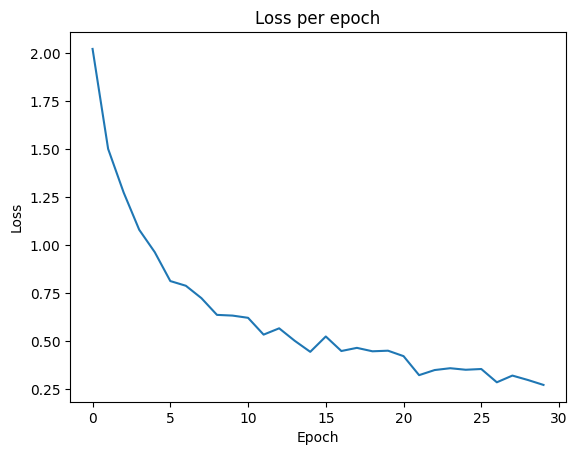

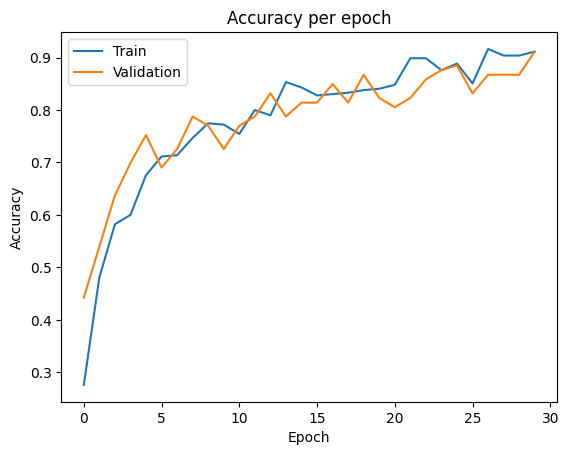

In [47]:
model_4 = FrogNet_4(num_classes=10).to(device)
optimizer_4 = optim.Adam(model_4.parameters(), lr=0.001)
num_epochs = 30

losses, train_acc, val_acc = training_model(model=model_4, train_loader=train_loader, val_loader=val_loader, criterion=criterion, 
                                            optimizer=optimizer_4, num_epochs=num_epochs, device=device)

In [48]:
show_classification_report(model_4, test_loader, device)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.90      1.00      0.95         9
           2       0.80      0.80      0.80         5
           3       0.71      1.00      0.83         5
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         8
           6       0.83      1.00      0.91         5
           7       0.80      0.80      0.80         5
           8       1.00      0.80      0.89         5
           9       1.00      0.80      0.89         5

    accuracy                           0.89        57
   macro avg       0.90      0.85      0.86        57
weighted avg       0.91      0.89      0.89        57



<h4>Confusion matrix na najlepszym dotrenowanym modelu</h4>

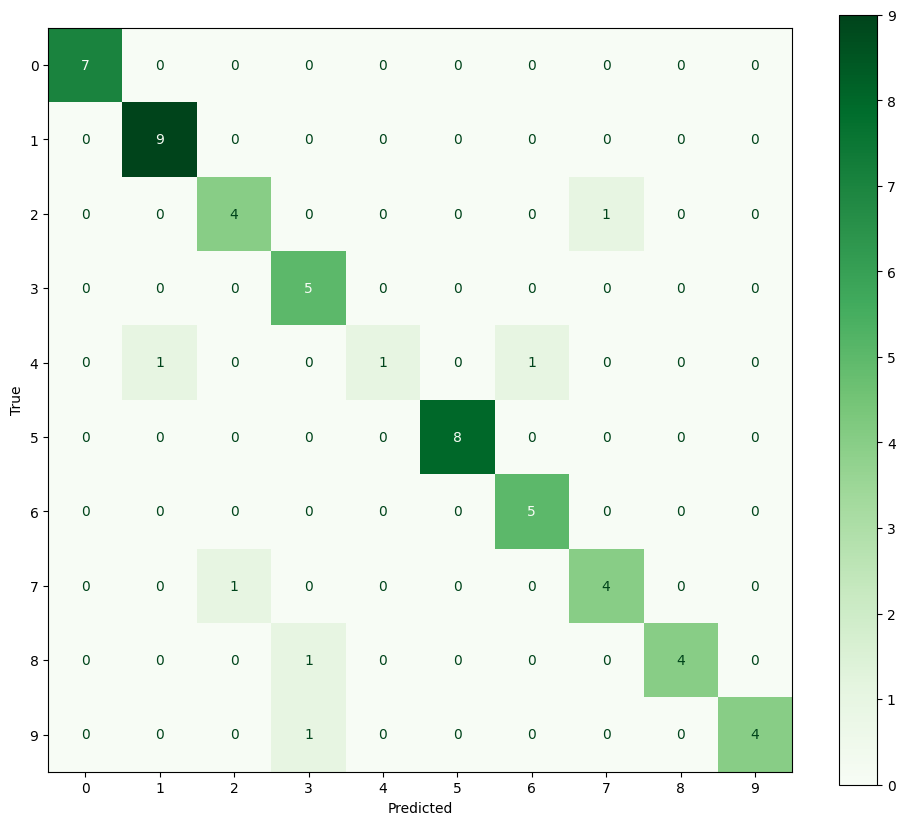

In [49]:
plot_confusion_matrix(model_4, test_loader)

<h3>Przyporządkowanie do konkretnego gatunku naszych odgłosów imitujących żaby przez najlepszy model</h3>

<h4> Przekonwertowanie plików z nagraniami z formatu .m4a na .wav za pomocą ffmpeg.</h4>

In [50]:
import os
from pydub import AudioSegment
from static_ffmpeg import add_paths 

In [51]:
add_paths() 

input_dir = "./data_ours"
our_wav_dir = "./data_ours_wav"

os.makedirs(our_wav_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    m4a_path = os.path.join(input_dir, filename)
    wav_filename = filename.replace('.m4a', '.wav')
    new_wav_path = os.path.join(our_wav_dir, wav_filename)
    
    audio = AudioSegment.from_file(m4a_path, format="m4a")
    audio.export(new_wav_path, format="wav")
        
    print(f"Przekonwertowano plik: {filename} na plik: {wav_filename}")

Przekonwertowano plik: Gabrysia.m4a na plik: Gabrysia.wav
Przekonwertowano plik: Jagoda.m4a na plik: Jagoda.wav


<h4>Wizualizacja odłgosów za pomocą wyżej zdefiniowanej funkcji load_sounds</h4>

In [52]:
gabrysia = load_sounds("./data_ours_wav/Gabrysia.wav") 
jagoda = load_sounds("./data_ours_wav/Jagoda.wav") 

_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=176128, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=212992, comptype='NONE', compname='not compressed')


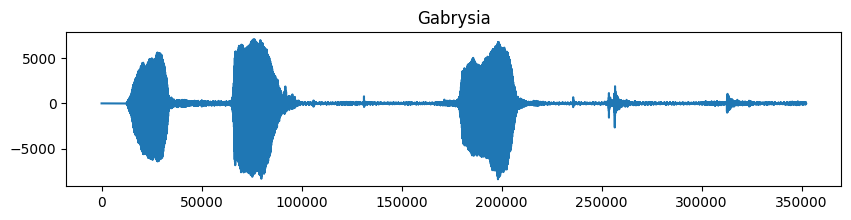

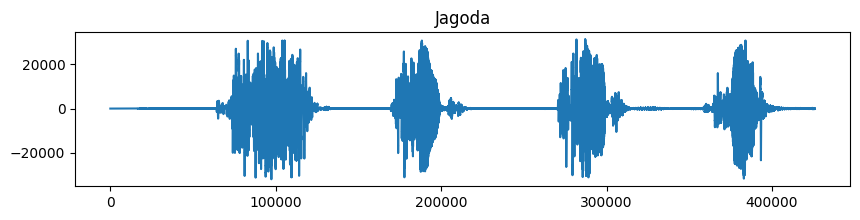

In [53]:
signals = [gabrysia, jagoda]
names = ["Gabrysia", "Jagoda"]

for sig, name in zip(signals, names):
    plt.figure(figsize=(10, 2)) 
    plt.plot(sig[:])
    plt.title(name)
    plt.show()

<h4>Zamiana plików .wav na reprezentację liczbową ponownie używając funkcji load_sounds</h4>

In [54]:
our_waves = {}
our_wav_dir = "./data_ours_wav"

for filename in os.listdir(our_wav_dir):
    full_path = os.path.join(our_wav_dir, filename)
    signal = load_sounds(full_path)
    key_name = filename.replace(".wav", "")
    our_waves[key_name] = signal

print(our_waves.keys())

_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=176128, comptype='NONE', compname='not compressed')
_wave_params(nchannels=2, sampwidth=2, framerate=48000, nframes=212992, comptype='NONE', compname='not compressed')
dict_keys(['Gabrysia', 'Jagoda'])


<h4>Wyrównanie długości nagrań</h4>

In [55]:
#Sprawdzenie jaką długość mają nasze nagrania
for name,s in our_waves.items():
    sampling_rate = 48000 #częstotliwość próbkowania (z parametrów plików .wav)
    n_channels = 2
    length = len(s)/(sampling_rate*n_channels) #obliczenie czasu trwania nagrania w sekundach
    print(f'Długość nargania {name} w sekundach: {length:.1f}')

Długość nargania Gabrysia w sekundach: 3.7
Długość nargania Jagoda w sekundach: 4.4


In [56]:
#Wyrównanie długośc nagrań do 2.5 sekund poprzez ich skrócenie
sampling_rate = 48000
n_channels = 2
target_len = int(2.5 * n_channels * sampling_rate)  #przeliczenie sekund na próbki

our_X = []
our_y = []

for key, signal in our_waves.items():
    processed_signal = signal[:target_len]
    our_X.append(processed_signal)
    our_y.append(key)
    
our_X = np.array(our_X)
our_y = np.array(our_y)
print(f"Krształt macierzy our_X: {our_X.shape}")

Krształt macierzy our_X: (2, 240000)


<h4>Standaryzacja danych</h4>

In [57]:
our_X_sc = scaler.transform(our_X)

<h4>Tworzenie tensorów</h4>

In [58]:
our_X_t = torch.tensor(our_X_sc, dtype=torch.float32).unsqueeze(1)

<h4>Klasyfikacja naszych odgłosów za pomocą najlepszego modelu</h4>

In [59]:
model_4.eval()

with torch.no_grad():
    outputs = model_4(our_X_t)
    predicted_classes = torch.argmax(outputs, dim=1).numpy()
for imie, przewidziana_klasa in zip(our_y, predicted_classes):  #łączenie tekstowowych imion z przewidzianymi klasami numerycznymi
    print(f"Dla nagrania {imie} model przewidział klasę: {przewidziana_klasa}")

Dla nagrania Gabrysia model przewidział klasę: 0
Dla nagrania Jagoda model przewidział klasę: 1


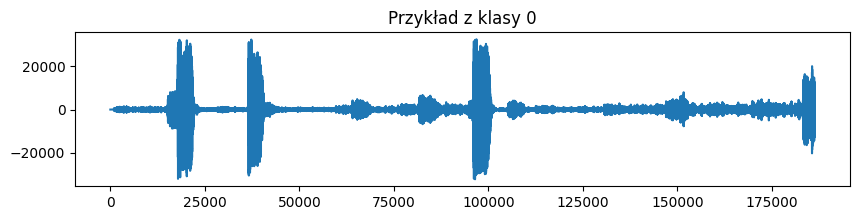

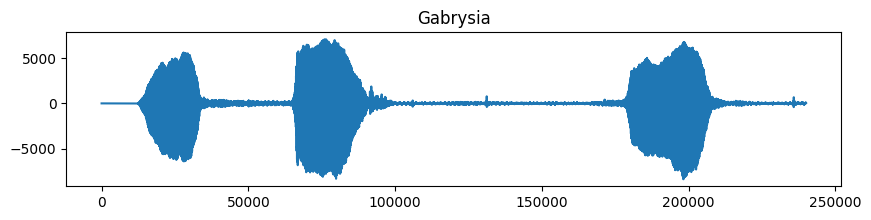

In [77]:
#Rysowanie nagrania z klasy 0 oraz nagrania Gabrysi dla porównania
class0_files = [k for k in waves.keys() if k.startswith('0')]
sample_class0 = waves[class0_files[1]][:target_len]  # przycięcie jednego z nagrań z klasy 9 do 2.5s

#przycięcie własnych nagrań do 2.5 sekund
gabrysia_cut = gabrysia[:target_len]

signals = [sample_class0, gabrysia_cut]
names = ["Przykład z klasy 0", "Gabrysia"]

for sig, name in zip(signals, names):
    plt.figure(figsize=(10, 2))
    plt.plot(sig)
    plt.title(name)
    plt.show()

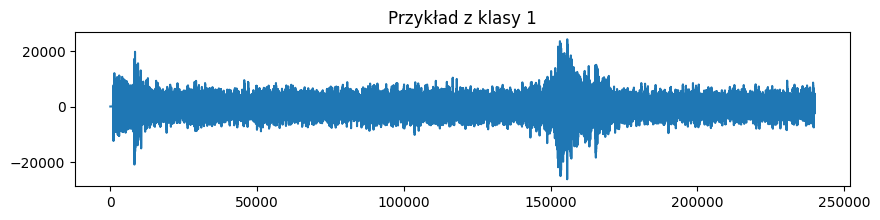

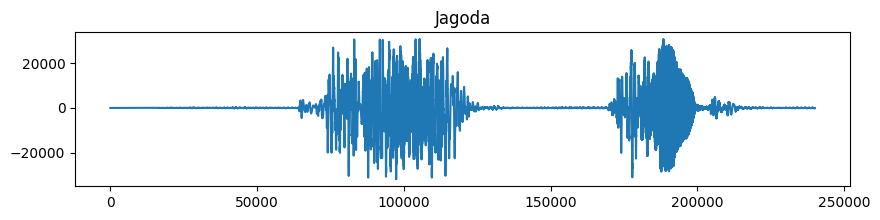

In [71]:
#Rysowanie nagrania z klasy 1 oraz nagrania Jagody dla porównania
class1_files = [k for k in waves.keys() if k.startswith('1')]
sample_class1 = waves[class1_files[4]][:target_len]  # przycięcie jednego z nagrań z klasy 1 do 2.5s

#przycięcie własnych nagrań do 2.5 sekund
jagoda_cut = jagoda[:target_len]

signals = [sample_class1, jagoda_cut]
names = ["Przykład z klasy 1", "Jagoda"]

for sig, name in zip(signals, names):
    plt.figure(figsize=(10, 2))
    plt.plot(sig)
    plt.title(name)
    plt.show()

<h4>Wyznaczenie prawdopodobieńśtwa z jakim model przypisałam daną klase do naszych nagrań</h4>

In [72]:
import torch.nn.functional as F

model_4.eval()

with torch.no_grad():
    outputs = model_4(our_X_t)
    probs = F.softmax(outputs, dim=1) # zamiana na prawdopodobieństwa procentowe

for i, imie in enumerate(our_y):
    osoba_probs = probs[i]
    pred = osoba_probs.argmax().item() #klasa z największym wynikiem dla tej osoby
    confidence = osoba_probs[pred].item() * 100
    
    print(f"{imie} → klasa {pred} ({confidence:.1f}%)")

Gabrysia → klasa 0 (46.3%)
Jagoda → klasa 1 (99.7%)


In [74]:
import torch.nn.functional as F

model_4.eval()

with torch.no_grad():
    outputs = model_4(our_X_t)
    probs = F.softmax(outputs, dim=1) # zamiana na prawdopodobieństwa procentowe

for i, imie in enumerate(our_y):
    osoba_probs = probs[i]
    pred = osoba_probs.argmax().item() #klasa z największym wynikiem dla tej osoby
    confidence = osoba_probs[pred].item() * 100
    
    print(f"{imie} → klasa {pred} ({confidence:.1f}%)")
    for klasa in range(osoba_probs.shape[0]):
        prob = osoba_probs[klasa].item() * 100
        print(f"  Klasa {klasa}: {prob:5.1f}%")

Gabrysia → klasa 0 (46.3%)
  Klasa 0:  46.3%
  Klasa 1:   0.7%
  Klasa 2:   5.0%
  Klasa 3:   1.2%
  Klasa 4:   1.0%
  Klasa 5:   0.4%
  Klasa 6:   0.1%
  Klasa 7:  18.0%
  Klasa 8:   2.4%
  Klasa 9:  25.0%
Jagoda → klasa 1 (99.7%)
  Klasa 0:   0.0%
  Klasa 1:  99.7%
  Klasa 2:   0.0%
  Klasa 3:   0.0%
  Klasa 4:   0.0%
  Klasa 5:   0.0%
  Klasa 6:   0.0%
  Klasa 7:   0.0%
  Klasa 8:   0.0%
  Klasa 9:   0.3%
